## Import des bibliothèques nécessaires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from scipy.stats import randint, uniform
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix, roc_curve)

from xgboost import XGBClassifier
import shap

c:\Users\kabir\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

In [3]:
# Paramètrage 
RANDOM_STATE = 42
TEST_SIZE = 0.2

target = 'resiliation'
id_col = "id_contrat"
path = r'C:\Users\kabir\OneDrive\Documents\master CNAM\Projets\Resilisation Clients\Portefeuille_assures.csv'

## 1. Chargement des données & Rapport qualité du Dataset

In [4]:
# Lecture des données
data = pd.read_csv(path, sep=',')

data.head(3)

,id_contrat,age_assure,anciennete_mois,garantie,nb_contrats_foyer,canal_souscription,mode_paiement,prime_annuelle,hausse_prime_pct,nb_sinistres_3ans,delai_reglement_moyen_jours,satisfaction_reglement,nb_contacts_reclamation_1an,nb_contacts_conseil_1an,score_nps,digital_engagement,resiliation
0,C100000,50,42,Auto,4,Comparateur en ligne,Annuel,462.92,2.6,2,9.0,9.5,0,0,7.6,0,0
1,C100001,29,40,Auto+Habitation,3,Conseiller téléphonique,Mensuel,481.04,13.9,0,NaN,NaN,1,1,4.4,1,0
2,C100002,56,101,Auto,1,Conseiller téléphonique,Mensuel,456.44,10.7,1,23.3,7.8,0,2,8.9,1,0


In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_contrat                   25000 non-null  object 
 1   age_assure                   25000 non-null  int64  
 2   anciennete_mois              25000 non-null  int64  
 3   garantie                     25000 non-null  object 
 4   nb_contrats_foyer            25000 non-null  int64  
 5   canal_souscription           25000 non-null  object 
 6   mode_paiement                25000 non-null  object 
 7   prime_annuelle               25000 non-null  float64
 8   hausse_prime_pct             25000 non-null  float64
 9   nb_sinistres_3ans            25000 non-null  int64  
 10  delai_reglement_moyen_jours  13632 non-null  float64
 11  satisfaction_reglement       13632 non-null  float64
 12  nb_contacts_reclamation_1an  25000 non-null  int64  
 13  nb_contacts_cons

In [6]:
numeric_features = [col for col in data.select_dtypes(include=np.number).columns.tolist() if col != target]
print("Variables numériques : ", numeric_features)

categorical_features = [col for col in data.select_dtypes(include=[object]).columns.tolist() if col != id_col]
print("Variables catégorielles : ", categorical_features)

features = numeric_features + categorical_features

Variables numériques :  ['age_assure', 'anciennete_mois', 'nb_contrats_foyer', 'prime_annuelle', 'hausse_prime_pct', 'nb_sinistres_3ans', 'delai_reglement_moyen_jours', 'satisfaction_reglement', 'nb_contacts_reclamation_1an', 'nb_contacts_conseil_1an', 'score_nps', 'digital_engagement']
Variables catégorielles :  ['garantie', 'canal_souscription', 'mode_paiement']


In [7]:
# Contrôle qualité des données 
def quality_report(df, name):
    
    print("\n" + "-"*35)
    print(f"  RAPPORT SYNTHÉTIQUE : {name}")
    print("-"*35)

    print(f"Nombre de lignes    : {df.shape[0]:,}")
    print(f"Nombre de colonnes  : {df.shape[1]}")

    print(f"Doublons : {df.duplicated().sum()}")

    print("Valeurs manquantes :")
    na = (df.isna()
          .sum()
          .loc[lambda x: x > 0]
          .sort_values(ascending=False)
    )

    if len(na) == 0:
        print("Aucune valeur manquante")
    else:
        display(pd.DataFrame({"Nb NA": na,
                              "%": (100 * na / len(df)).round(2)
            })
        )

In [8]:
quality_report(data, "Qualité des données de Résilisation Clients")


-----------------------------------
  RAPPORT SYNTHÉTIQUE : Qualité des données de Résilisation Clients
-----------------------------------
Nombre de lignes    : 25,000
Nombre de colonnes  : 17
Doublons : 0
Valeurs manquantes :


,Nb NA,%
delai_reglement_moyen_jours,11368,45.47
satisfaction_reglement,11368,45.47


## 2. Nettoyage des données

In [9]:
def nettoyage_donnees(df, num_cols, cat_cols):
    """
    Nettoie un DataFrame :
    - Variables numériques : remplace les NaN par la médiane.
    - Variables catégorielles : remplace les NaN par 'InfoManquante'.
    """

    df_clean = df.copy()

    # Remplacement des NaN des variables numériques par la médiane
    for col in num_cols:
        median = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median)

    # Remplacement des NaN des variables catégorielles
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna("InfoManquante")

    return df_clean

In [10]:
df = nettoyage_donnees(data, numeric_features, categorical_features)
quality_report(df, "Données après nettoyage")



-----------------------------------
  RAPPORT SYNTHÉTIQUE : Données après nettoyage
-----------------------------------
Nombre de lignes    : 25,000
Nombre de colonnes  : 17
Doublons : 0
Valeurs manquantes :
Aucune valeur manquante


## 3. Analyse exploratoire des données - EDA

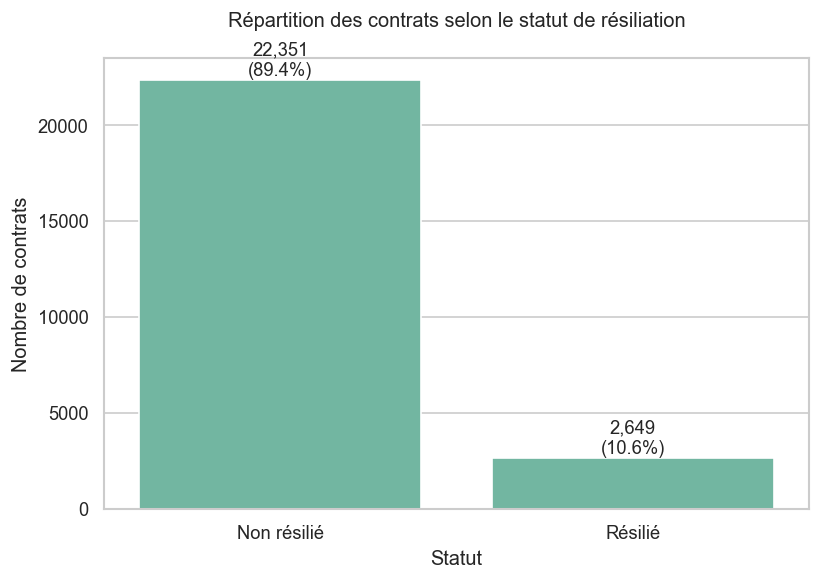

In [11]:
repartition = df[target].value_counts().sort_index()
pourcentages = df[target].value_counts(normalize=True).sort_index() * 100

labels = ["Non résilié", "Résilié"]

plt.figure(figsize=(7, 5))

ax = sns.barplot(x=labels,
                 y=repartition.values
)

for i, (nombre, pourcentage) in enumerate(
    zip(repartition.values, pourcentages.values)
):
    ax.text(i, nombre,
        f"{nombre:,}\n({pourcentage:.1f}%)",
        ha="center", va="bottom",
        fontsize=11
    )

plt.title("Répartition des contrats selon le statut de résiliation\n")
plt.xlabel("Statut")
plt.ylabel("Nombre de contrats")

plt.tight_layout()
plt.show()

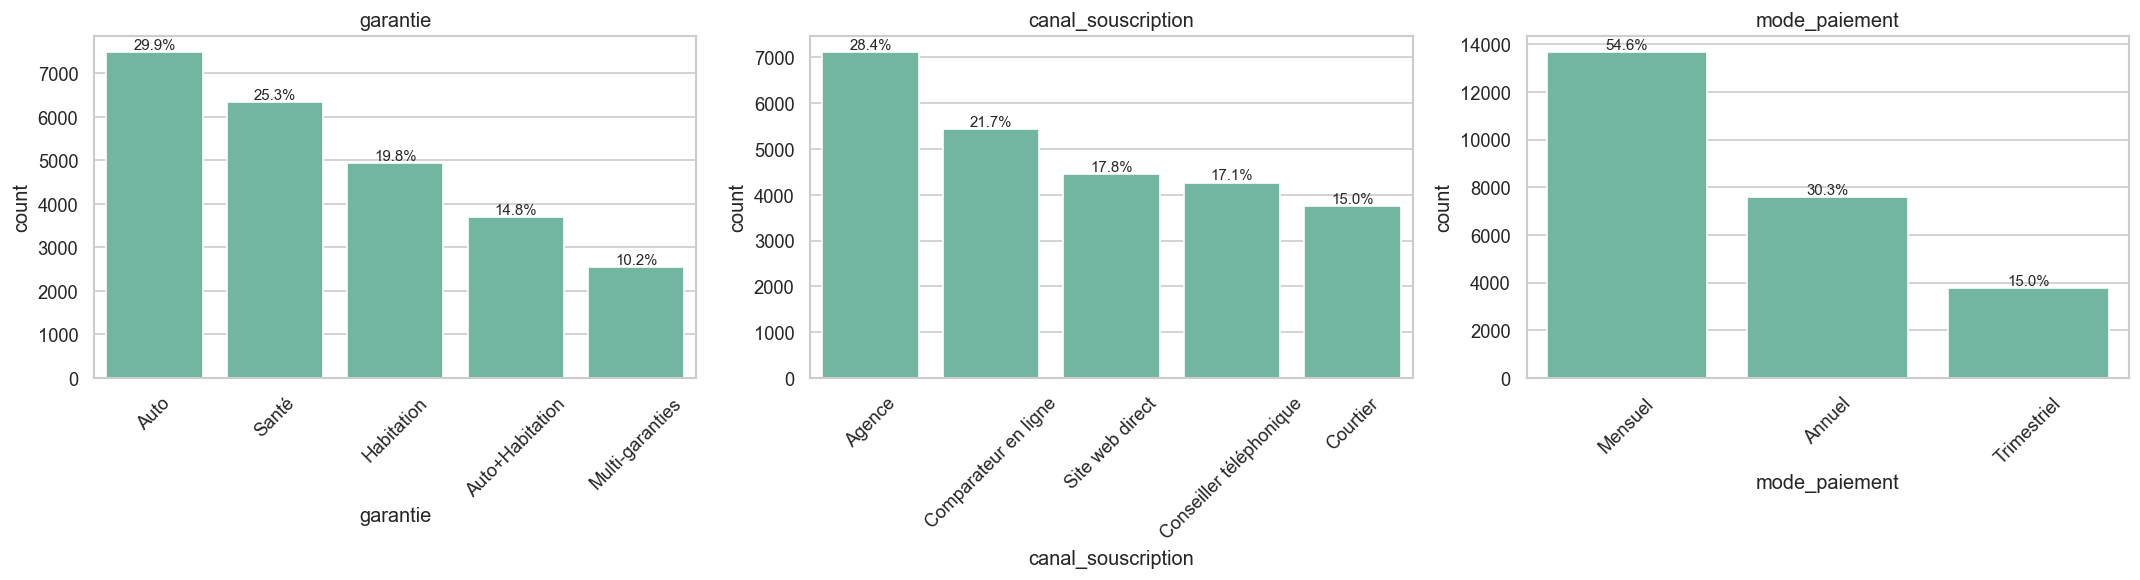

In [12]:
# Visualisation des variables catégorielles
# Nombre de graphiques par ligne
ncols = 3
nrows = math.ceil(len(categorical_features) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax = sns.countplot(data=df,
                       x=col,
                       order=df[col].value_counts().index,
                       ax=axes[i]
    )

    total = len(df)

    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center',
                    va='bottom',
                    fontsize=9)

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

# Suppression des axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
def taux_resiliation_global(df, target):
    """
    Calcule le taux de résiliation global.
    """
    taux = df[target].mean()
    return f' Sur les {len(df)} clients, {taux*100:.2f}% ont résilié leur contrat'

taux_resiliation_global(df, target)

' Sur les 25000 clients, 10.60% ont résilié leur contrat'

In [14]:
def taux_par_segment(df, segment, target):
    """
    Calcule le taux de résiliation par modalité d'une variable.
    """
    tab = (df.groupby(segment)[target]
             .agg(Taux_resiliation="mean",
                  Nb_contrats="size")
             .sort_values("Taux_resiliation", ascending=False)
    )

    tab["Taux_resiliation"] = (tab["Taux_resiliation"] * 100).round(2)

    return tab.reset_index()

In [15]:
display("Taux de résiliation par Garantie",taux_par_segment(df, "garantie", target))
display("Taux de résiliation par Canal de Souscription",taux_par_segment(df, "canal_souscription", target))
display("Taux de résiliation par Mode de Paiement",taux_par_segment(df, "mode_paiement", target))

'Taux de résiliation par Garantie'

,garantie,Taux_resiliation,Nb_contrats
0,Santé,11.61,6332
1,Habitation,10.54,4943
2,Auto,10.42,7479
3,Multi-garanties,10.27,2552
4,Auto+Habitation,9.53,3694


'Taux de résiliation par Canal de Souscription'

,canal_souscription,Taux_resiliation,Nb_contrats
0,Comparateur en ligne,17.49,5432
1,Site web direct,10.55,4446
2,Conseiller téléphonique,9.57,4265
3,Courtier,8.56,3749
4,Agence,7.05,7108


'Taux de résiliation par Mode de Paiement'

,mode_paiement,Taux_resiliation,Nb_contrats
0,Mensuel,12.63,13657
1,Trimestriel,8.57,3759
2,Annuel,7.94,7584


In [16]:
def plot_taux_par_segment(df, segment, target):
    """
    Affiche le taux de résiliation par modalité.
    """

    tab = taux_par_segment(df, segment, target)

    plt.figure(figsize=(7,5))

    ax = sns.barplot(data=tab,
                     x=segment,
                     y="Taux_resiliation",
                     order=tab[segment]
    )

    for barre in ax.patches:

        ax.annotate(f"{barre.get_height():.1f}%",
                    (barre.get_x() + barre.get_width()/2, barre.get_height()),
                    ha="center",
                    va="bottom"
        )

    plt.title(f"Taux de résiliation par {segment}")
    plt.ylabel("Taux de résiliation (%)")
    plt.xlabel(segment)
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

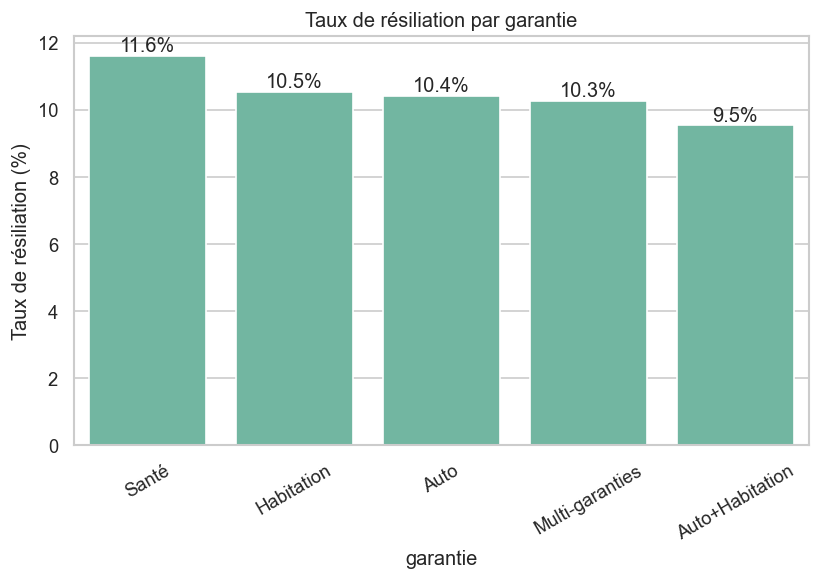

None

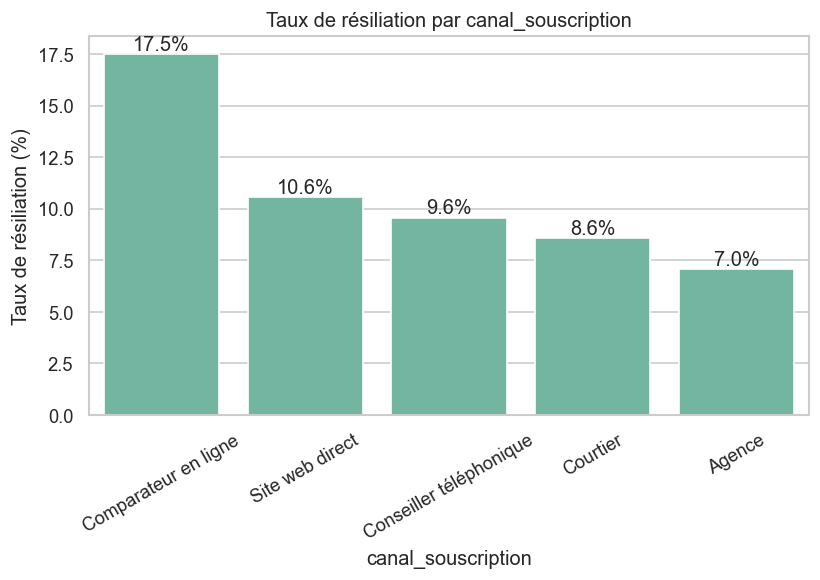

None

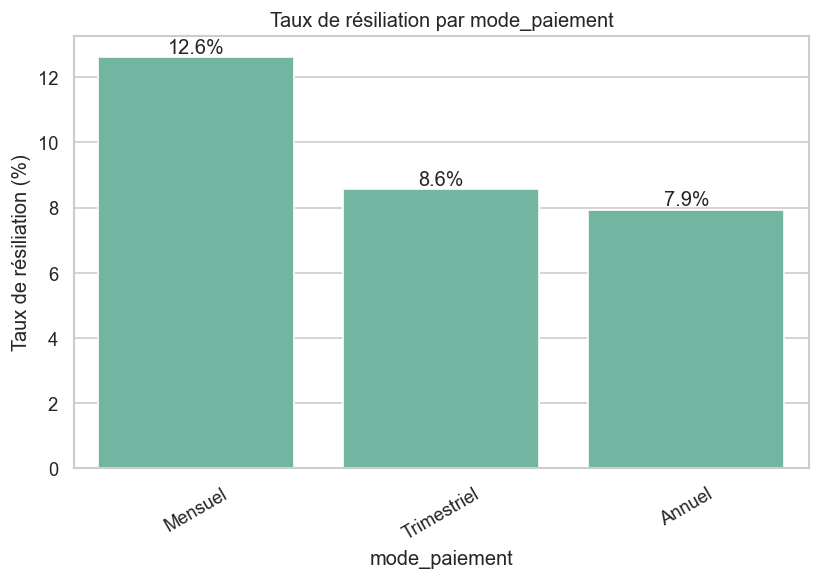

None

In [17]:
display(plot_taux_par_segment(df, "garantie", target))
display(plot_taux_par_segment(df, "canal_souscription", target))
display(plot_taux_par_segment(df, "mode_paiement", target))

In [18]:
def plot_hausse_prime_vs_churn(df, target):
    
    df = df.copy()

    df["tranche_hausse"] = pd.cut(df["hausse_prime_pct"],
                                  bins=[-10,0,5,10,15,20,30,100],
                                  labels=["<0%", "0-5%", "5-10%", "10-15%", "15-20%", "20-30%", ">30%"]
    )

    tab = (df.groupby("tranche_hausse", observed=True)[target]
             .mean()*100
    )

    plt.figure(figsize=(8,5))

    tab.plot(kind="bar")

    plt.title("Effet de la hausse de prime")
    plt.ylabel("Taux de résiliation (%)")
    plt.xlabel("Hausse de prime")

    plt.tight_layout()
    plt.show()

    return tab

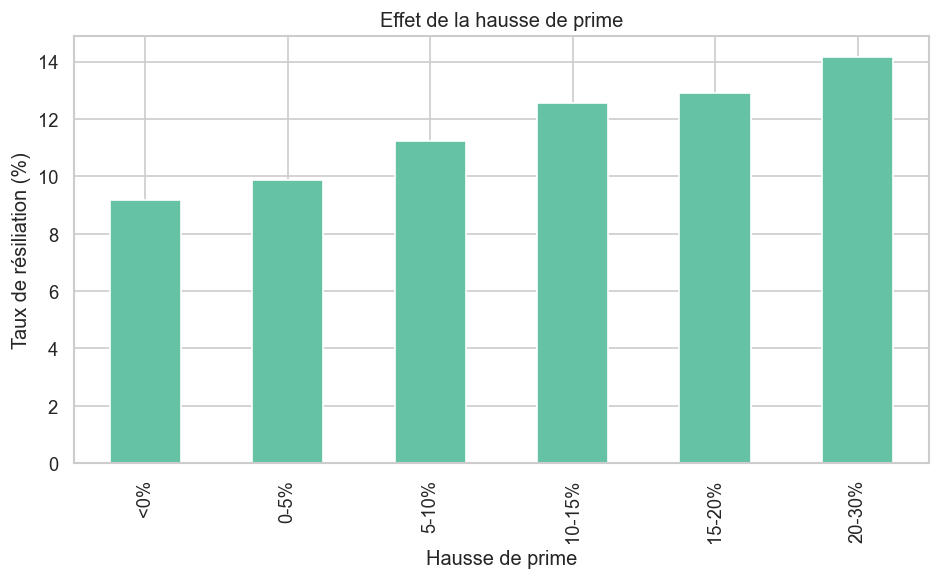

tranche_hausse
<0%        9.185947
0-5%       9.883117
5-10%     11.247878
10-15%    12.547865
15-20%    12.903226
20-30%    14.179104
Name: resiliation, dtype: float64

In [19]:
plot_hausse_prime_vs_churn(df, target)

In [20]:
def plot_anciennete_vs_churn(df, target):
    
    df = df.copy()

    df["tranche_anciennete"] = pd.cut(df["anciennete_mois"],
                                      bins=[0,6,12,24,36,60,120,240],
                                      labels=["0-6m", "6-12m", "1-2 ans", "2-3 ans", "3-5 ans", "5-10 ans", "10 ans +"]
    )

    tab = (df.groupby("tranche_anciennete", observed=True)[target]
             .mean()*100
    )

    plt.figure(figsize=(8,5))

    tab.plot(marker="o")

    plt.title("Résiliation selon l'ancienneté")
    plt.ylabel("Taux de résiliation (%)")
    plt.xlabel("Ancienneté")

    plt.tight_layout()
    plt.show()

    return tab

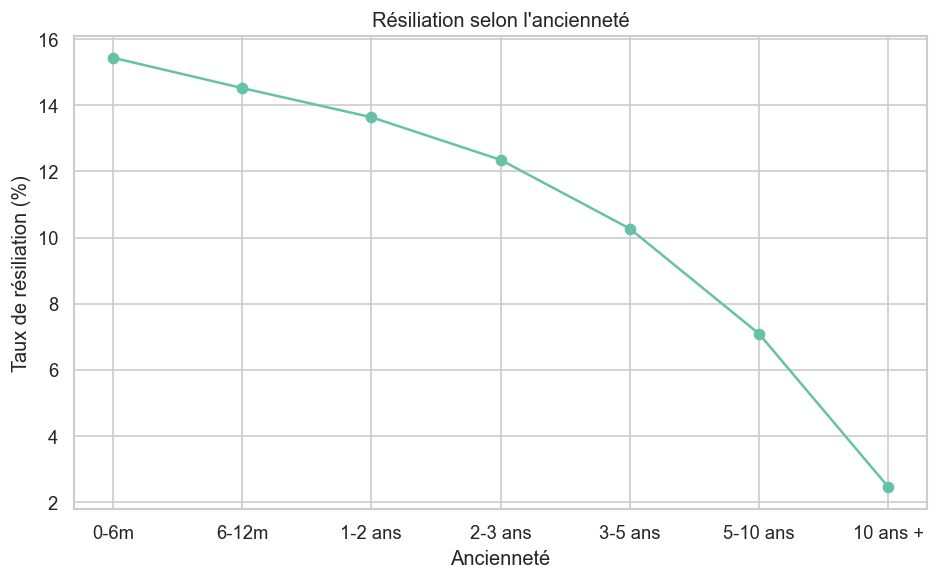

tranche_anciennete
0-6m        15.444015
6-12m       14.524806
1-2 ans     13.642596
2-3 ans     12.352021
3-5 ans     10.268396
5-10 ans     7.084155
10 ans +     2.446483
Name: resiliation, dtype: float64

In [21]:
plot_anciennete_vs_churn(df, target)

In [22]:
def matrice_correlation(df, variables_numeriques, target):
    
    corr = (df[variables_numeriques + [target]].corr(numeric_only=True))

    plt.figure(figsize=(10,8))

    sns.heatmap(corr,
                annot=True,
                cmap="coolwarm",
                center=0,
                fmt=".2f"
    )

    plt.title("Matrice de corrélation")

    plt.tight_layout()
    plt.show()

    return corr

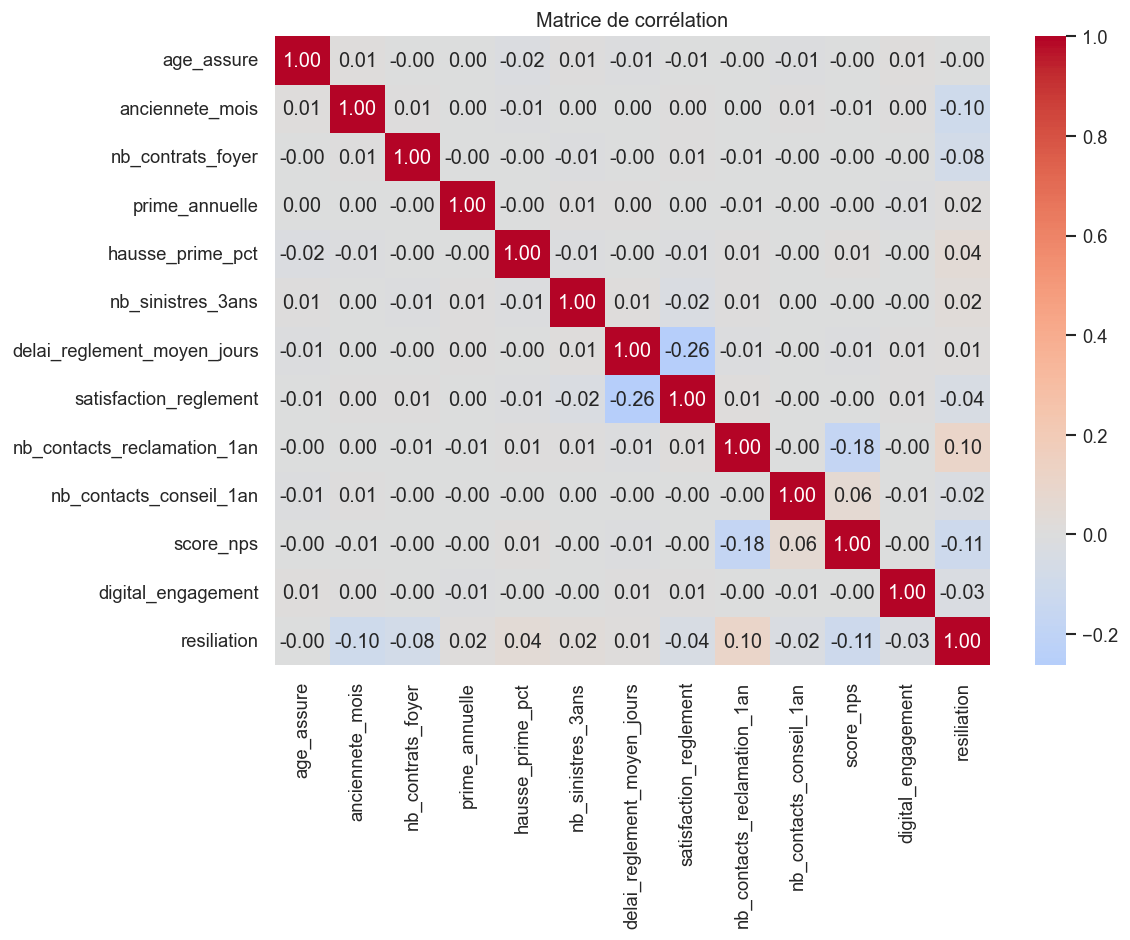

,age_assure,anciennete_mois,nb_contrats_foyer,prime_annuelle,hausse_prime_pct,nb_sinistres_3ans,delai_reglement_moyen_jours,satisfaction_reglement,nb_contacts_reclamation_1an,nb_contacts_conseil_1an,score_nps,digital_engagement,resiliation
age_assure,1.000000,0.013291,-0.001648,0.001950,-0.018046,0.005699,-0.006566,-0.005100,-0.003503,-0.009306,-0.001163,0.009838,-0.001674
anciennete_mois,0.013291,1.000000,0.007377,0.003130,-0.008270,0.000284,0.000597,0.004674,0.001779,0.005771,-0.005478,0.003666,-0.100921
nb_contrats_foyer,-0.001648,0.007377,1.000000,-0.002169,-0.001789,-0.010207,-0.001319,0.008510,-0.005503,-0.004144,-0.001492,-0.002261,-0.076522
prime_annuelle,0.001950,0.003130,-0.002169,1.000000,-0.002304,0.007244,0.004165,0.001513,-0.005668,-0.003478,-0.001598,-0.008353,0.015563
hausse_prime_pct,-0.018046,-0.008270,-0.001789,-0.002304,1.000000,-0.011981,-0.000401,-0.008274,0.005570,-0.000517,0.011905,-0.001067,0.040461
nb_sinistres_3ans,0.005699,0.000284,-0.010207,0.007244,-0.011981,1.000000,0.014371,-0.021781,0.005384,0.003238,-0.001717,-0.004530,0.024865
delai_reglement_moyen_jours,-0.006566,0.000597,-0.001319,0.004165,-0.000401,0.014371,1.000000,-0.262786,-0.006982,-0.002503,-0.006570,0.005237,0.014460
satisfaction_reglement,-0.005100,0.004674,0.008510,0.001513,-0.008274,-0.021781,-0.262786,1.000000,0.014054,-0.001303,-0.001793,0.006349,-0.040733
nb_contacts_reclamation_1an,-0.003503,0.001779,-0.005503,-0.005668,0.005570,0.005384,-0.006982,0.014054,1.000000,-0.003364,-0.176272,-0.001683,0.104420
nb_contacts_conseil_1an,-0.009306,0.005771,-0.004144,-0.003478,-0.000517,0.003238,-0.002503,-0.001303,-0.003364,1.000000,0.061937,-0.005743,-0.022025


In [23]:
matrice_correlation(df, numeric_features, target)

## 4. Preprocessing 

In [24]:
X = df[numeric_features + categorical_features]
y = df[target]

In [25]:
# Train / Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y,
                                                           test_size=TEST_SIZE, random_state= RANDOM_STATE
)



In [26]:
def preprocesseur(num_vars, cat_vars):
    
    preprocessor = ColumnTransformer(transformers=[("num", "passthrough", num_vars),
                                                   ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_vars)
                                                  ]
    )

    return preprocessor

# num_vars non standardisées pour l'interprétabilité des coefficients SHAP

In [27]:
# Entrainement du préprocesseur 
preprocessor = preprocesseur(numeric_features, categorical_features)
preprocessor.fit(X_train_raw)

# Transformation 
X_train = preprocessor.transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Récupération des noms des variables après transformation
feature_names = preprocessor.get_feature_names_out()

## 5. Modélisation + Evaluation 

In [28]:
# Fonction d'avaluation 
def evaluate(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    return {"Nom": name,
            "Modèle": model,
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "F1-score": f1_score(y_test, y_pred),
            "Précision": precision_score(y_test, y_pred,
                                         zero_division=0),
            "Rappel": recall_score(y_test, y_pred),
            "Prédictions": y_pred,
            "Probabilités": y_proba,
            "Matrice": confusion_matrix(y_test, y_pred),
            "Pipeline" : None, 
            "Meilleurs paramètres": None
    }

In [29]:
# Régression logistique 
def fit_logistic_regression(X_train, y_train, X_test, y_test):
    
    model = LogisticRegression(max_iter=2000,
                               solver="newton-cholesky",
                               class_weight="balanced",
                               random_state=RANDOM_STATE
    )

    param_dist = {"C": uniform(0.01, 10)}

    search = RandomizedSearchCV(estimator=model,
                                param_distributions=param_dist,
                                n_iter=15,
                                scoring="roc_auc",
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                                random_state=RANDOM_STATE,
                                n_jobs=-1
    )

    search.fit(X_train, y_train)

    result = evaluate("Régression logistique",
                      search.best_estimator_,
                      X_test,
                      y_test
    )

    best_pipeline = search.best_estimator_
    result["Pipeline"] = best_pipeline 
    result["Meilleurs paramètres"] = search.best_params_

    return result

In [30]:
# Random Forest
def fit_random_forest(X_train, y_train, X_test, y_test):
    
    model = RandomForestClassifier(class_weight="balanced",
                                   random_state=RANDOM_STATE,
                                   n_jobs=-1
    )

    param_dist = {"n_estimators": randint(200, 600),
                  "max_depth": randint(4, 20),
                  "min_samples_leaf": randint(5, 50),
                  "max_features": uniform(0.3, 0.6)
    }

    search = RandomizedSearchCV(estimator=model,
                                param_distributions=param_dist,
                                n_iter=20,
                                scoring="roc_auc",
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                                random_state=RANDOM_STATE,
                                n_jobs=-1
    )

    search.fit(X_train, y_train)

    result = evaluate("Random Forest",
                      search.best_estimator_,
                      X_test,
                      y_test
    )
    best_pipeline = search.best_estimator_

    result["Pipeline"] = best_pipeline
    result["Meilleurs paramètres"] = search.best_params_

    return result

In [31]:
# XG_BOOST
def fit_xgboost( X_train, y_train, X_test, y_test):
    
    scale_pos_weight = ((y_train == 0).sum()/ (y_train == 1).sum())

    model = XGBClassifier(objective="binary:logistic",
                          eval_metric="auc",
                          scale_pos_weight=scale_pos_weight,
                          random_state=RANDOM_STATE,
                          n_jobs=-1
    )

    param_dist = {"n_estimators": randint(150, 500),
                  "max_depth": randint(3, 10),
                  "learning_rate": uniform(0.01, 0.25),
                  "subsample": uniform(0.6, 0.4),
                  "colsample_bytree": uniform(0.6, 0.4),
                  "min_child_weight": randint(1, 10)
    }

    search = RandomizedSearchCV(estimator=model,
                                param_distributions=param_dist,
                                n_iter=25,
                                scoring="roc_auc",
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                                random_state=RANDOM_STATE,
                                n_jobs=-1
    )

    search.fit(X_train, y_train)

    result = evaluate("XGBoost",
                      search.best_estimator_,
                      X_test,
                      y_test
    )
    best_pipeline = search.best_estimator_

    result["Pipeline"]= best_pipeline
    result["Meilleurs paramètres"] = search.best_params_

    return result

In [32]:
# Comparaison des modèles 
def compare_models(*results):
    
    comparaison = pd.DataFrame({"Modèle":[r["Nom"] for r in results],
                                "ROC-AUC":[r["ROC-AUC"] for r in results],
                                "F1-score":[r["F1-score"] for r in results],
                                "Précision":[r["Précision"] for r in results],
                                "Rappel":[r["Rappel"] for r in results]
    })

    return comparaison.sort_values(by="ROC-AUC",
                                   ascending=False
    )

In [33]:
# Courbe ROC
def plot_roc_curves(results, y_test):
    
    plt.figure(figsize=(8,6))

    for r in results:

        fpr, tpr, _ = roc_curve(y_test,
                                r["Probabilités"]
        )

        plt.plot(fpr, tpr,
                 label=f'{r["Nom"]} ({r["ROC-AUC"]:.3f})'
        )

    plt.plot([0,1],[0,1],"k--")
    plt.legend()
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.title("Comparaison des courbes ROC")

    plt.show()

In [34]:
# Matrice de confusion 
def plot_confusion_matrix(result):
    
    plt.figure(figsize=(5,4))

    sns.heatmap(result["Matrice"],
                annot=True,
                fmt="d",
                cmap="Blues"
    )

    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title(result["Nom"])

    plt.show()

In [35]:
# Résultats 
logit = fit_logistic_regression(X_train, y_train,
                                X_test, y_test
)

In [36]:
rf = fit_random_forest(X_train, y_train,
                       X_test, y_test
)

In [37]:
xgb = fit_xgboost(X_train, y_train,
                  X_test, y_test
)

In [38]:
compare_models(logit,
               rf,
               xgb
)

,Modèle,ROC-AUC,F1-score,Précision,Rappel
0,Régression logistique,0.723495,0.309415,0.200646,0.675725
2,XGBoost,0.720274,0.312562,0.214966,0.572464
1,Random Forest,0.712889,0.317195,0.228916,0.516304


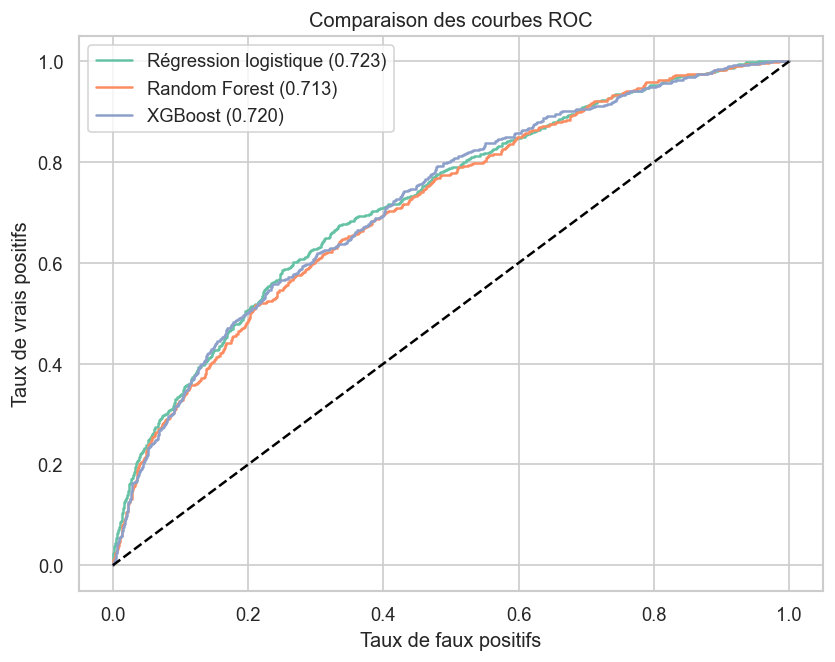

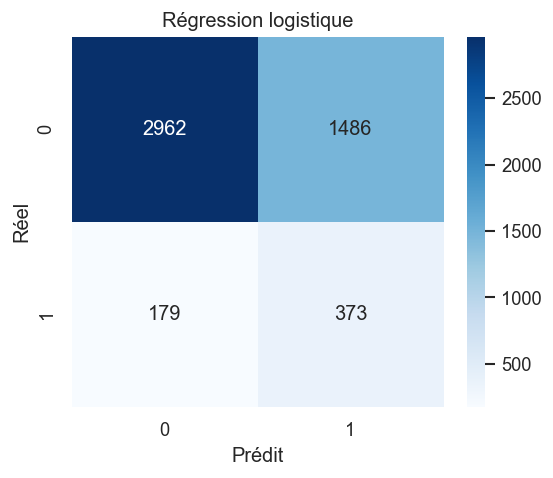

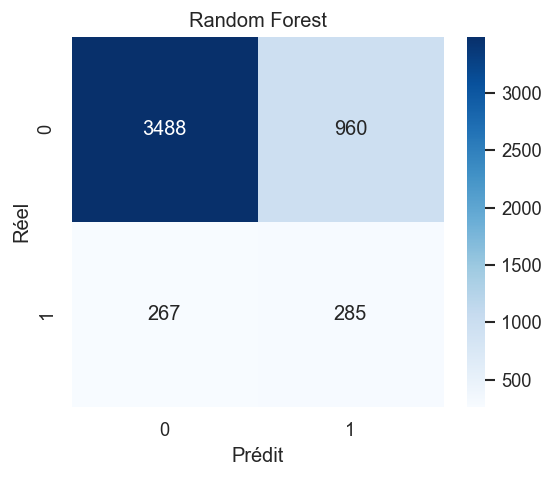

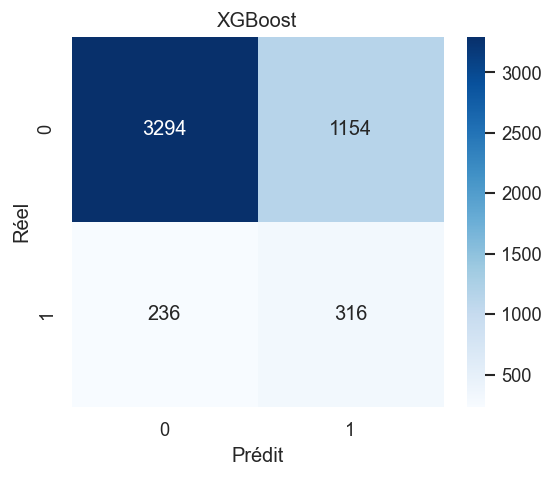

In [39]:
plot_roc_curves([logit, rf, xgb],
                y_test
)

plot_confusion_matrix(logit)
plot_confusion_matrix(rf)
plot_confusion_matrix(xgb)

## 6. Interprétation des résultats

### 6.1. Importance des variables avec les coefficients

In [40]:
def plot_model_importance(model, feature_names, model_name,
                          top_n=15, figsize=(9, 6)
):
    """
    Affiche et retourne l'importance des variables d'un modèle.

    - Régression logistique : coefficients
    - Random Forest / XGBoost : feature_importances_

    -------
    pd.DataFrame
        Tableau contenant les variables, leur importance
        et leur direction lorsque disponible.
    """

   
    # Récupération de l'importance
    if hasattr(model, "coef_"):
        # Régression logistique
        coefficients = model.coef_[0]

        importance_df = pd.DataFrame({"Variable": feature_names,
                                      "Coefficient": coefficients,
                                      "Importance": np.abs(coefficients)
        })

        importance_type = "Coefficient"

    elif hasattr(model, "feature_importances_"):
        # Random Forest / XGBoost
        importances = model.feature_importances_

        importance_df = pd.DataFrame({"Variable": feature_names,
                                      "Importance": importances
        })

        importance_type = "Feature importance"

    else:
        raise ValueError("Le modèle ne possède ni 'coef_' ni 'feature_importances_'.")

    # Classement
    importance_df = (importance_df
                     .sort_values("Importance", ascending=False)
                     .reset_index(drop=True)
    )

    # Sélection des variables
    top_features = (importance_df
                    .head(top_n)
                    .sort_values("Importance", ascending=True)
    )

    # Graphique
    plt.figure(figsize=figsize)

    # Régression logistique
    if hasattr(model, "coef_"):

        plt.barh(top_features["Variable"],
                 top_features["Coefficient"]
        )

        plt.axvline(0,
                    linestyle="--",
                    linewidth=1
        )

        plt.xlabel("Coefficient")
        plt.title(f"Importance des variables — {model_name}")

    # Random Forest / XGBoost
    else:

        plt.barh(top_features["Variable"],
                 top_features["Importance"]
        )

        plt.xlabel("Importance")
        plt.title(f"Importance des variables — {model_name}")

    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

    return importance_df

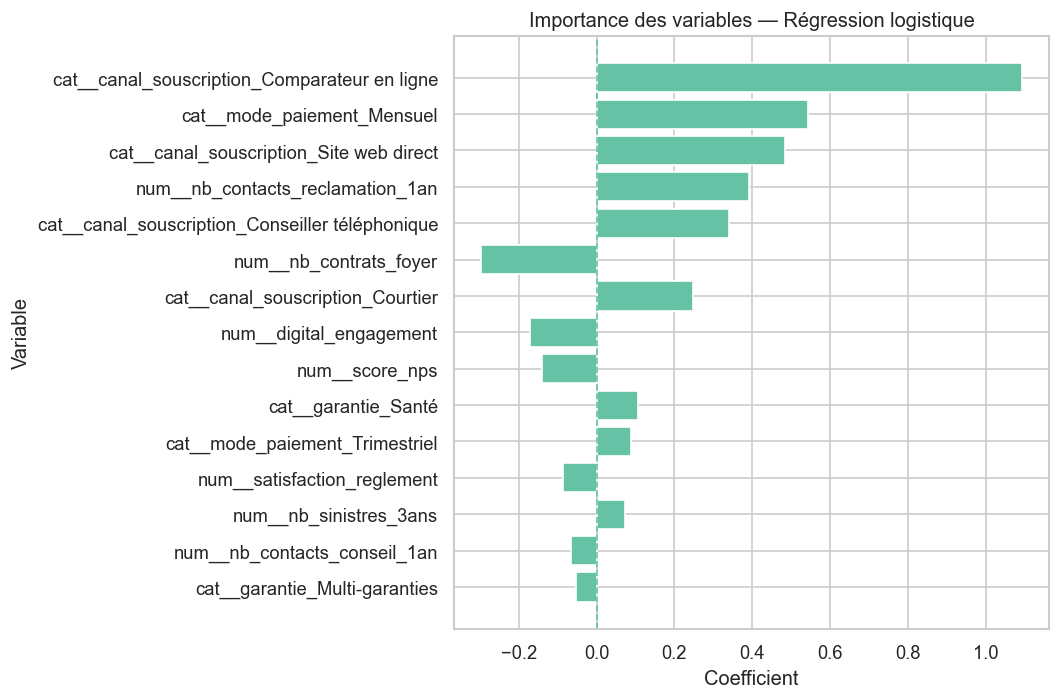

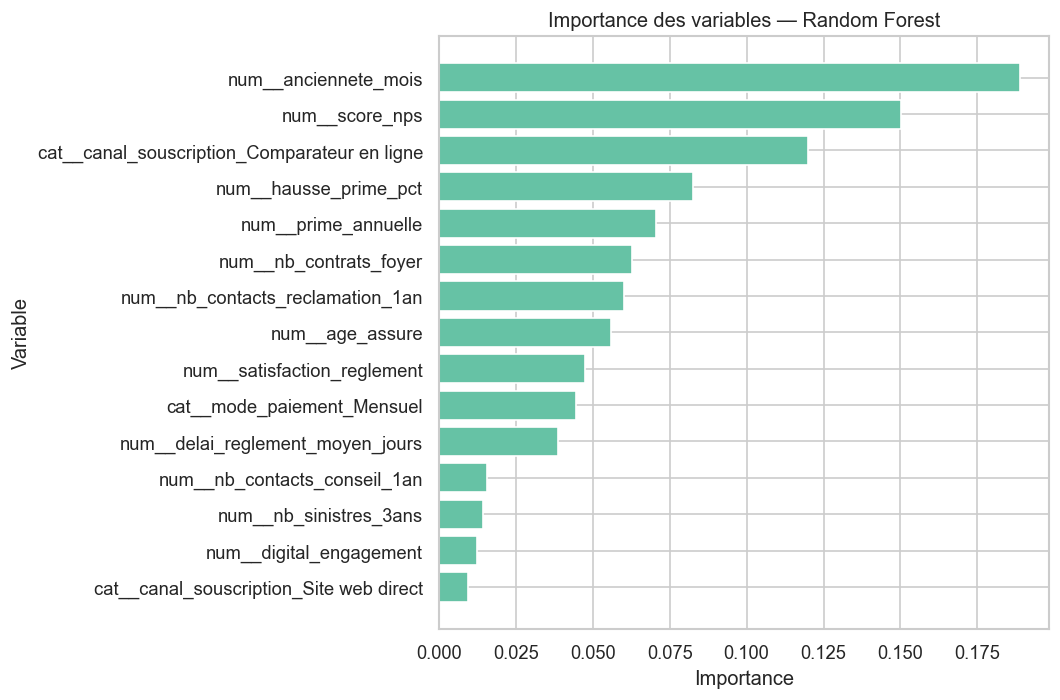

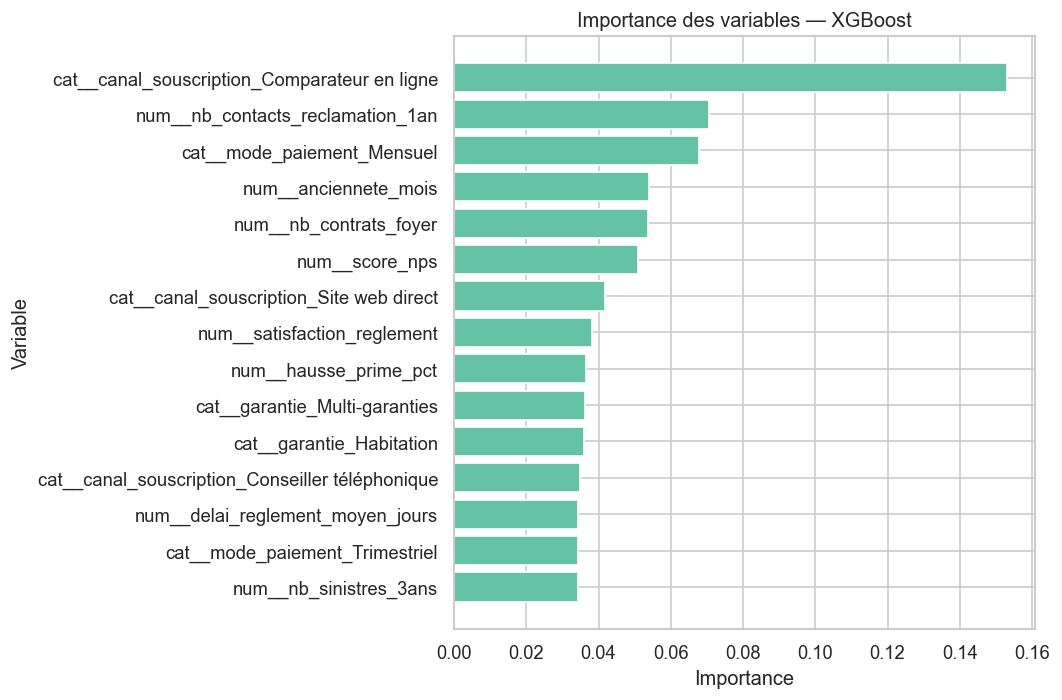

In [41]:
importance_logit = plot_model_importance(logit["Modèle"], feature_names, "Régression logistique", top_n=15)
importance_rf = plot_model_importance(rf["Modèle"], feature_names, "Random Forest", top_n=15)
importance_xgb = plot_model_importance(xgb["Modèle"], feature_names, "XGBoost", top_n=15)

In [42]:
importance_logit

,Variable,Coefficient,Importance
0,cat__canal_souscription_Comparateur en ligne,1.092339,1.092339
1,cat__mode_paiement_Mensuel,0.542977,0.542977
2,cat__canal_souscription_Site web direct,0.483878,0.483878
3,num__nb_contacts_reclamation_1an,0.390967,0.390967
4,cat__canal_souscription_Conseiller téléphonique,0.340591,0.340591
5,num__nb_contrats_foyer,-0.296614,0.296614
6,cat__canal_souscription_Courtier,0.247741,0.247741
7,num__digital_engagement,-0.171586,0.171586
8,num__score_nps,-0.141015,0.141015
9,cat__garantie_Santé,0.107353,0.107353


In [43]:
importance_rf

,Variable,Importance
0,num__anciennete_mois,0.188771
1,num__score_nps,0.150282
2,cat__canal_souscription_Comparateur en ligne,0.119862
3,num__hausse_prime_pct,0.082506
4,num__prime_annuelle,0.070524
5,num__nb_contrats_foyer,0.062740
6,num__nb_contacts_reclamation_1an,0.060122
7,num__age_assure,0.055922
8,num__satisfaction_reglement,0.047543
9,cat__mode_paiement_Mensuel,0.044489


In [44]:
importance_xgb

,Variable,Importance
0,cat__canal_souscription_Comparateur en ligne,0.153115
1,num__nb_contacts_reclamation_1an,0.070455
2,cat__mode_paiement_Mensuel,0.067806
3,num__anciennete_mois,0.053980
4,num__nb_contrats_foyer,0.053805
5,num__score_nps,0.050995
6,cat__canal_souscription_Site web direct,0.041913
7,num__satisfaction_reglement,0.038233
8,num__hausse_prime_pct,0.036615
9,cat__garantie_Multi-garanties,0.036169


### 6.2. Vue globale avec SHAP

In [45]:
def compute_shap_values(model, X_data, feature_names, model_type="tree"):
    """
    Calcule les valeurs SHAP d'un modèle entraîné.

    Parameters
    ----------
    model :
        Modèle sklearn entraîné.

    X_data :
        Données transformées après préprocessing.

    feature_names :
        Noms des variables après transformation.

    model_type :
        "tree" pour RandomForest/XGBoost
        "linear" pour LogisticRegression

    Returns
    -------
    shap_values :
        Valeurs SHAP

    X_shap :
        DataFrame avec les variables transformées.
    """

    # Passage en DataFrame pour garder les noms
    X_shap = pd.DataFrame(X_data, columns=feature_names)


    # Modèles arbres
    if model_type == "tree":
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)

    # Modèle linéaire
    elif model_type == "linear":
        masker = shap.maskers.Independent(X_shap, max_samples=X_shap.shape[0])
        explainer = shap.LinearExplainer(model, masker)
        shap_values = explainer.shap_values(X_shap)

    else:
        raise ValueError("model_type doit être 'tree' ou 'linear'")


    # Cas classification binaire
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    elif (isinstance(shap_values, np.ndarray)
          and shap_values.ndim == 3
    ):
        shap_values = shap_values[:,:,1]


    return shap_values, X_shap

In [46]:
def plot_shap_summary(shap_values,
                      X_shap,
                      max_display=15):

    plt.figure(figsize=(10,6))

    shap.summary_plot(shap_values, X_shap,
                      max_display=max_display
    )

    plt.show()

In [47]:
# Importance des variables SHAP
def top_features_shap(shap_values,
                      X_shap,
                      top_n=10 ):

    importance = (np.abs(shap_values).mean(axis=0))

    result = pd.DataFrame({"Variable": X_shap.columns,
                           "Importance_SHAP": importance
    })


    return (result.sort_values("Importance_SHAP",
                               ascending=False).head(top_n)
                                               .reset_index(drop=True)
    )

                                        Variable  Importance_SHAP
0   cat__canal_souscription_Comparateur en ligne         0.065985
1                           num__anciennete_mois         0.059749
2                                 num__score_nps         0.051658
3               num__nb_contacts_reclamation_1an         0.037730
4                     cat__mode_paiement_Mensuel         0.036023
5                         num__nb_contrats_foyer         0.033313
6                          num__hausse_prime_pct         0.021229
7                    num__satisfaction_reglement         0.015425
8                            num__prime_annuelle         0.008540
9               num__delai_reglement_moyen_jours         0.007901
10                               num__age_assure         0.007362
11                        num__nb_sinistres_3ans         0.005845
12       cat__canal_souscription_Site web direct         0.005713
13                       num__digital_engagement         0.005156
14        

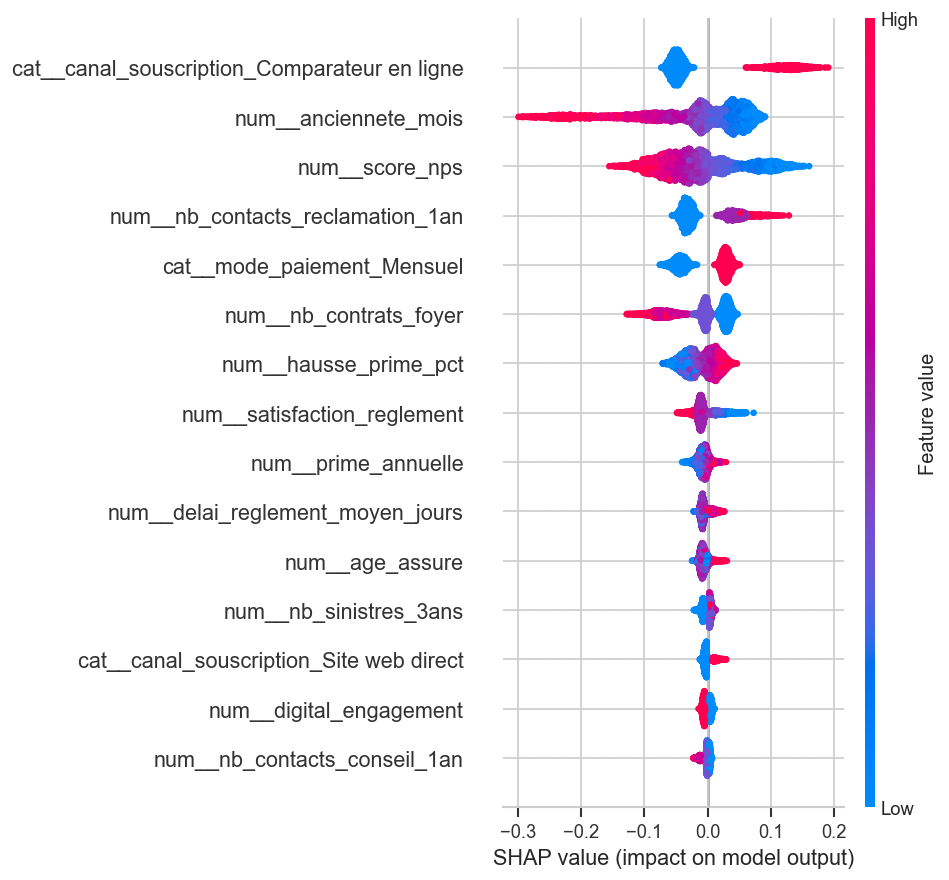

In [48]:
# Résultat cas du Random Forest
shap_rf, X_shap_rf = compute_shap_values(model=rf["Modèle"],
                                         X_data=X_test,
                                         feature_names=feature_names,
                                         model_type="tree"
)

print(top_features_shap(shap_rf, X_shap_rf, top_n=15))

plot_shap_summary(shap_rf, X_shap_rf, max_display=15)

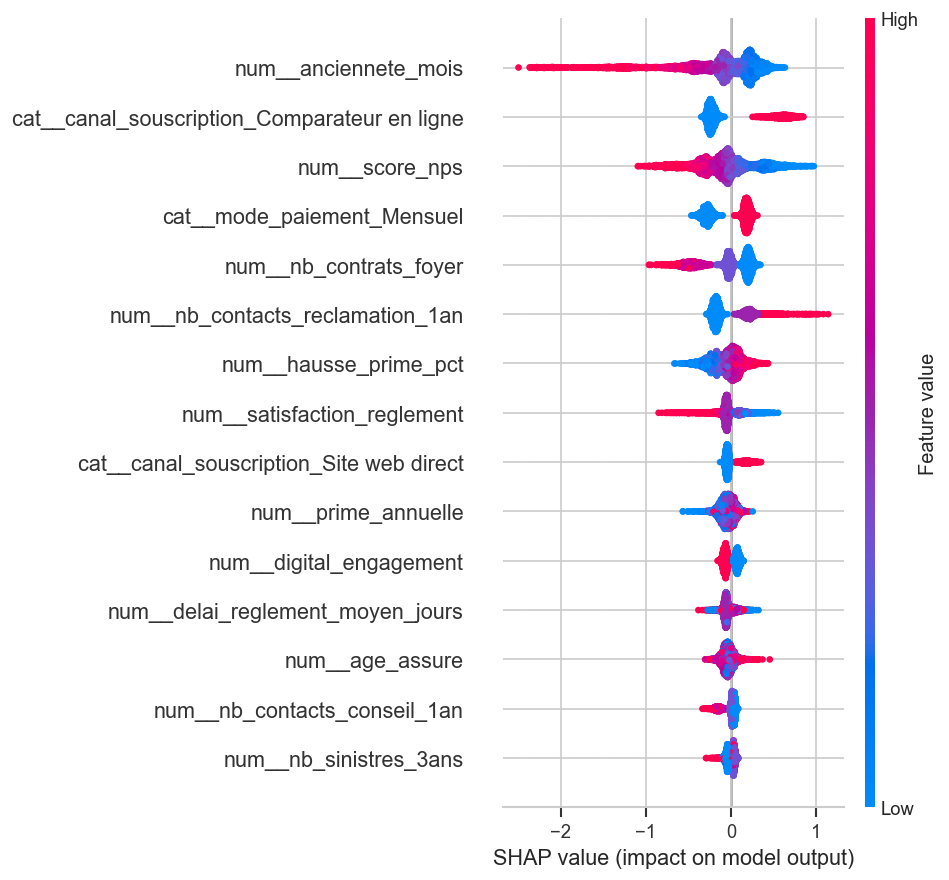

In [49]:
# XGBoost 
shap_xgb, X_shap_xgb = compute_shap_values(xgb["Modèle"],
                                           X_test,
                                           feature_names,
                                           model_type="tree"
)


plot_shap_summary(shap_xgb, X_shap_xgb)

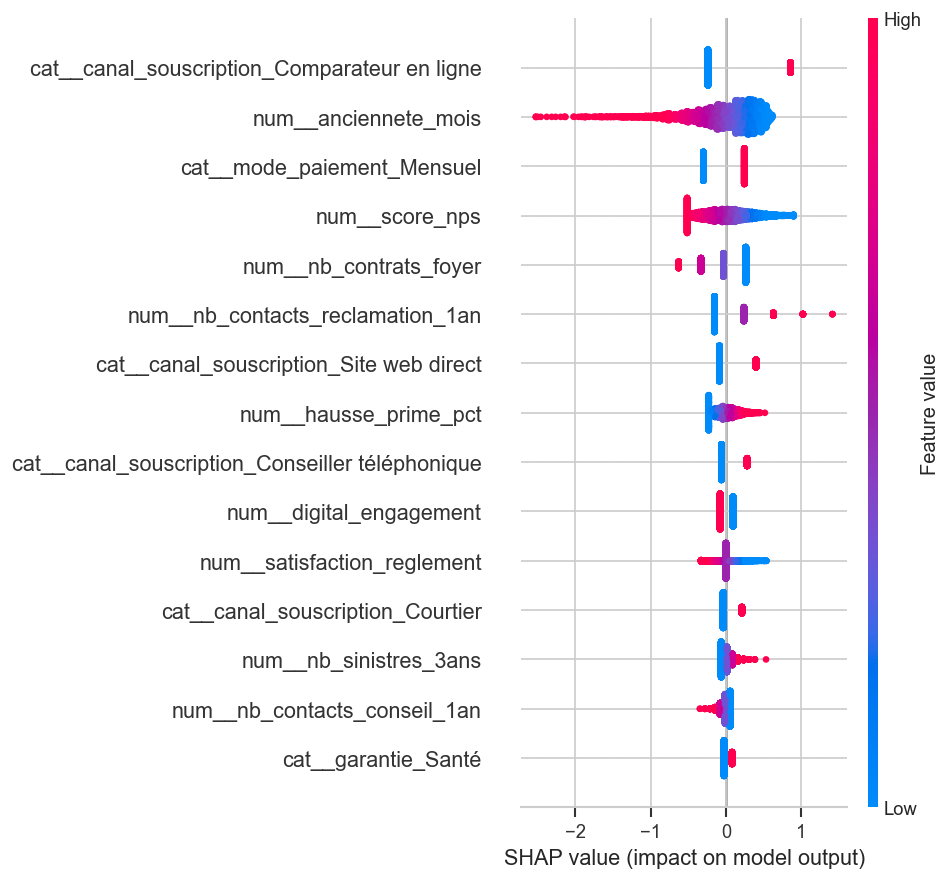

In [50]:
# Regression logistique
shap_logit, X_shap_logit = compute_shap_values(logit["Modèle"],
                                               X_test,
                                               feature_names,
                                               model_type="linear"
)

plot_shap_summary(shap_logit, X_shap_logit)

### 6.3. Vue locale des valeurs SHAP

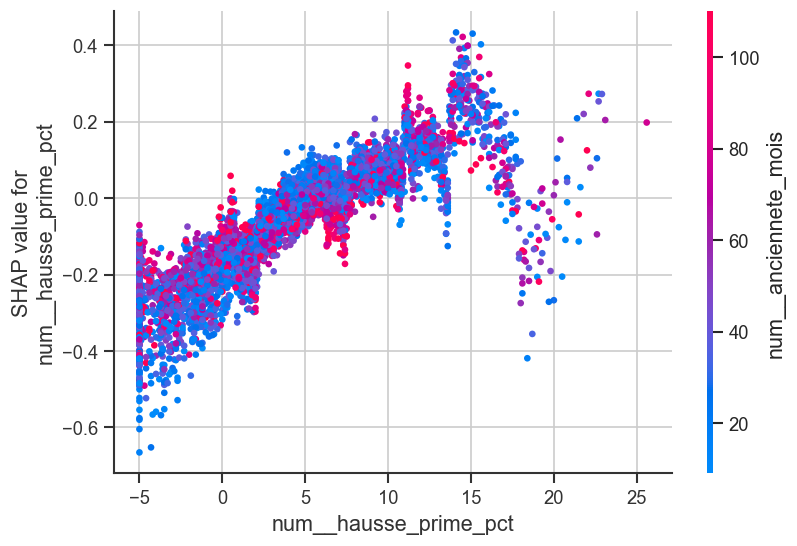

In [51]:
shap.dependence_plot("num__hausse_prime_pct",
                     shap_xgb,
                     X_shap_xgb
)

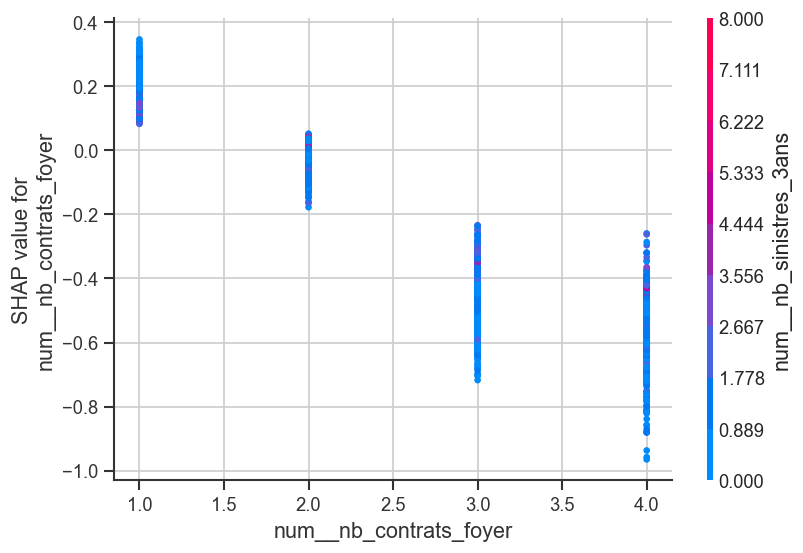

In [53]:
shap.dependence_plot("num__nb_contrats_foyer",
                     shap_xgb,
                     X_shap_xgb
)

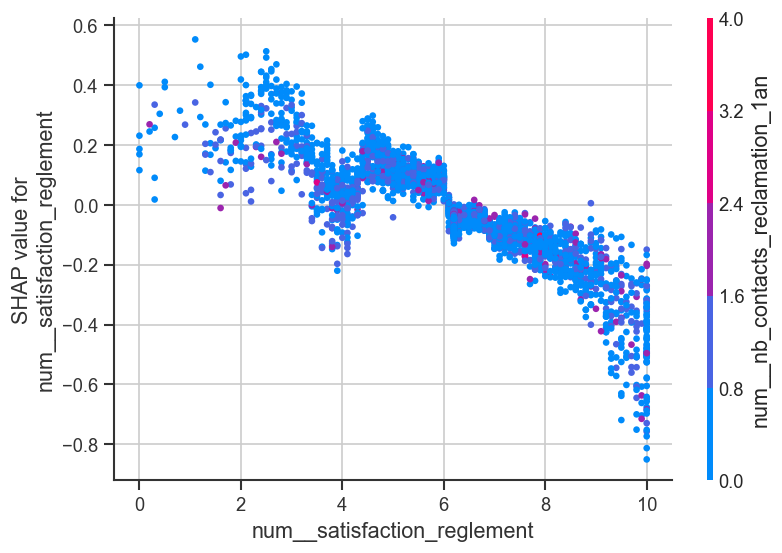

In [54]:
shap.dependence_plot("num__satisfaction_reglement",
                     shap_xgb,
                     X_shap_xgb
)

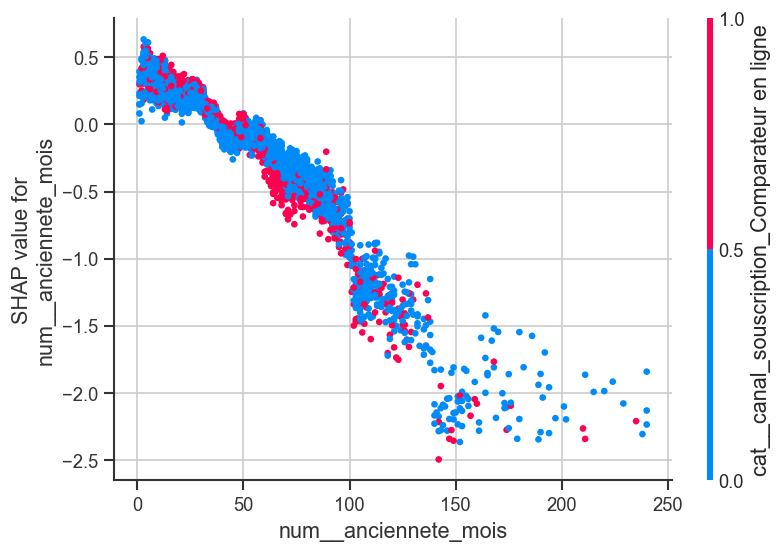

In [55]:
shap.dependence_plot("num__anciennete_mois",
                     shap_xgb,
                     X_shap_xgb
)